In [2]:
import pandas as pd
import numpy as np

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
#● Load the California Housing dataset using the fetch_california_housing function from sklearn.
from sklearn.datasets import fetch_california_housing
california = fetch_california_housing()
california

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [4]:
#● Convert the dataset into a pandas DataFrame for easier handling.
df=pd.DataFrame(california.data,columns=california.feature_names)
df['Target']=california.target

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [6]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'Target'],
      dtype='object')

In [7]:
df.shape

(20640, 9)

In [8]:
#Handle missing values 
df.isna().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Target        0
dtype: int64

If all values are 0, there are no missing values, so no imputation is required.

In [9]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'MedInc'),
  Text(1, 0, 'HouseAge'),
  Text(2, 0, 'AveRooms'),
  Text(3, 0, 'AveBedrms'),
  Text(4, 0, 'Population'),
  Text(5, 0, 'AveOccup'),
  Text(6, 0, 'Latitude'),
  Text(7, 0, 'Longitude'),
  Text(8, 0, 'Target')])

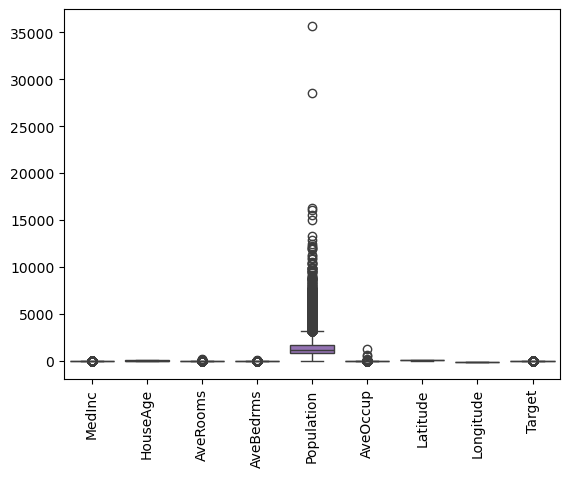

In [10]:

import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(data=df)
plt.xticks(rotation=90)

Outliers were identified using box plots. The points outside the whiskers represent possible outliers. The box plot shows that some outlier values.

In [11]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_count = ((df < lower) | (df > upper)).sum()
print(outlier_count)

MedInc         681
HouseAge         0
AveRooms       511
AveBedrms     1424
Population    1196
AveOccup       711
Latitude         0
Longitude        0
Target        1071
dtype: int64


The IQR method was used to identify outliers. MedInc, AveRooms, AveBedrms, Population, AveOccup andTarget contain outliers, while HouseAge, Latitude, and Longitude have no outliers

Q1: 2.5633999999999997
Q3: 4.74325
IQR: 2.17985
lower_bound: -0.7063750000000004
upper_bound: 8.013024999999999
Number of outliers: 681


([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'MedInc'),
  Text(1, 0, 'HouseAge'),
  Text(2, 0, 'AveRooms'),
  Text(3, 0, 'AveBedrms'),
  Text(4, 0, 'Population'),
  Text(5, 0, 'AveOccup'),
  Text(6, 0, 'Latitude'),
  Text(7, 0, 'Longitude'),
  Text(8, 0, 'Target')])

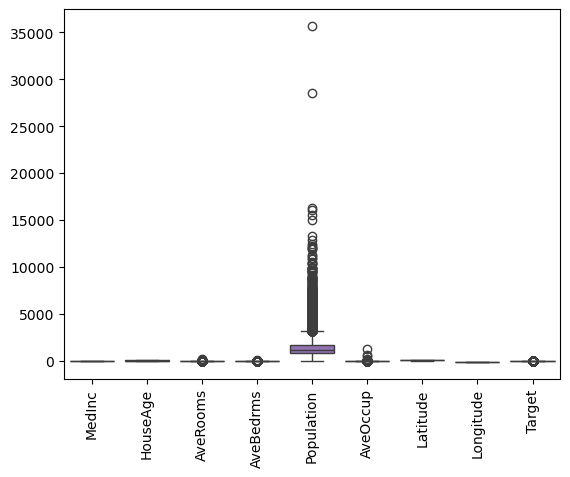

In [12]:
#Remove outliers in MedInc
Q1=np.percentile(df['MedInc'],25)
Q3=np.percentile(df['MedInc'],75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
print("Q1:",Q1)
print("Q3:",Q3)
print("IQR:",IQR)
print("lower_bound:",lower_bound)
print("upper_bound:",upper_bound)
outliers=df[(df['MedInc']<lower_bound)|(df['MedInc']>upper_bound)]
print("Number of outliers:",len(outliers))
outliers
#clipping outliers
df['MedInc']=df['MedInc'].clip(lower_bound,upper_bound)
sns.boxplot(data=df)
plt.xticks(rotation=90)

Q1: 4.440716235896959
Q3: 6.052380952380952
IQR: 1.6116647164839932
lower_bound: 2.023219161170969
upper_bound: 8.469878027106942
Number of outliers: 511


([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'MedInc'),
  Text(1, 0, 'HouseAge'),
  Text(2, 0, 'AveRooms'),
  Text(3, 0, 'AveBedrms'),
  Text(4, 0, 'Population'),
  Text(5, 0, 'AveOccup'),
  Text(6, 0, 'Latitude'),
  Text(7, 0, 'Longitude'),
  Text(8, 0, 'Target')])

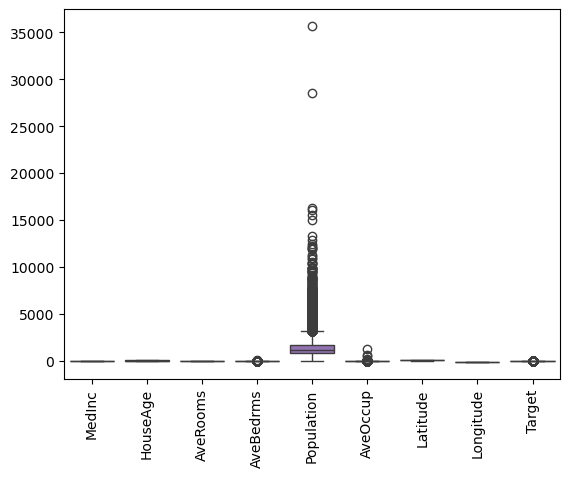

In [13]:
#Remove outliers in AveRooms
Q1=np.percentile(df['AveRooms'],25)
Q3=np.percentile(df['AveRooms'],75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
print("Q1:",Q1)
print("Q3:",Q3)
print("IQR:",IQR)
print("lower_bound:",lower_bound)
print("upper_bound:",upper_bound)
outliers=df[(df['AveRooms']<lower_bound)|(df['AveRooms']>upper_bound)]
print("Number of outliers:",len(outliers))
outliers
#clipping outliers
df['AveRooms']=df['AveRooms'].clip(lower_bound,upper_bound)
sns.boxplot(data=df)
plt.xticks(rotation=90)

Q1: 1.006079046038478
Q3: 1.099526066350711
IQR: 0.09344702031223284
lower_bound: 0.8659085155701288
upper_bound: 1.2396965968190603
Number of outliers: 1424


([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'MedInc'),
  Text(1, 0, 'HouseAge'),
  Text(2, 0, 'AveRooms'),
  Text(3, 0, 'AveBedrms'),
  Text(4, 0, 'Population'),
  Text(5, 0, 'AveOccup'),
  Text(6, 0, 'Latitude'),
  Text(7, 0, 'Longitude'),
  Text(8, 0, 'Target')])

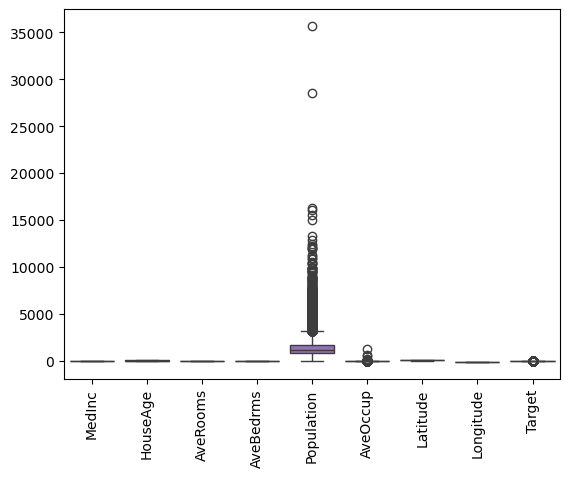

In [14]:
#Remove outliers in AveBedrms
Q1=np.percentile(df['AveBedrms'],25)
Q3=np.percentile(df['AveBedrms'],75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
print("Q1:",Q1)
print("Q3:",Q3)
print("IQR:",IQR)
print("lower_bound:",lower_bound)
print("upper_bound:",upper_bound)
outliers=df[(df['AveBedrms']<lower_bound)|(df['AveBedrms']>upper_bound)]
print("Number of outliers:",len(outliers))
outliers
#clipping outliers
df['AveBedrms']=df['AveBedrms'].clip(lower_bound,upper_bound)
sns.boxplot(data=df)
plt.xticks(rotation=90)

Q1: 787.0
Q3: 1725.0
IQR: 938.0
lower_bound: -620.0
upper_bound: 3132.0
Number of outliers: 1196


([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'MedInc'),
  Text(1, 0, 'HouseAge'),
  Text(2, 0, 'AveRooms'),
  Text(3, 0, 'AveBedrms'),
  Text(4, 0, 'Population'),
  Text(5, 0, 'AveOccup'),
  Text(6, 0, 'Latitude'),
  Text(7, 0, 'Longitude'),
  Text(8, 0, 'Target')])

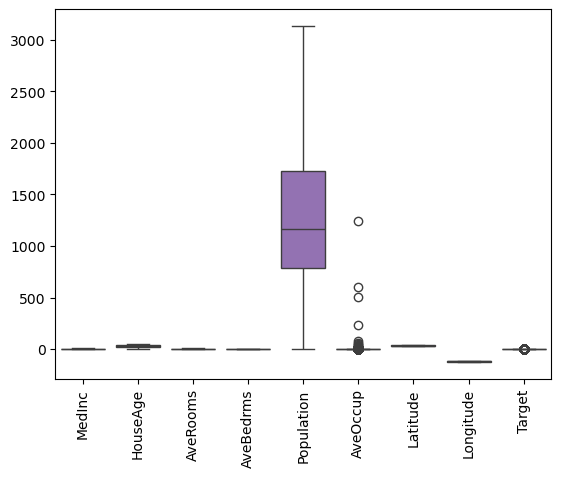

In [15]:
#Remove outliers in population
Q1=np.percentile(df['Population'],25)
Q3=np.percentile(df['Population'],75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
print("Q1:",Q1)
print("Q3:",Q3)
print("IQR:",IQR)
print("lower_bound:",lower_bound)
print("upper_bound:",upper_bound)
outliers=df[(df['Population']<lower_bound)|(df['Population']>upper_bound)]
print("Number of outliers:",len(outliers))
outliers
#clipping outliers
df['Population']=df['Population'].clip(lower_bound,upper_bound)
sns.boxplot(data=df)
plt.xticks(rotation=90)

Q1: 2.4297411475535755
Q3: 3.2822609242736216
IQR: 0.8525197767200461
lower_bound: 1.1509614824735064
upper_bound: 4.5610405893536905
Number of outliers: 711


([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'MedInc'),
  Text(1, 0, 'HouseAge'),
  Text(2, 0, 'AveRooms'),
  Text(3, 0, 'AveBedrms'),
  Text(4, 0, 'Population'),
  Text(5, 0, 'AveOccup'),
  Text(6, 0, 'Latitude'),
  Text(7, 0, 'Longitude'),
  Text(8, 0, 'Target')])

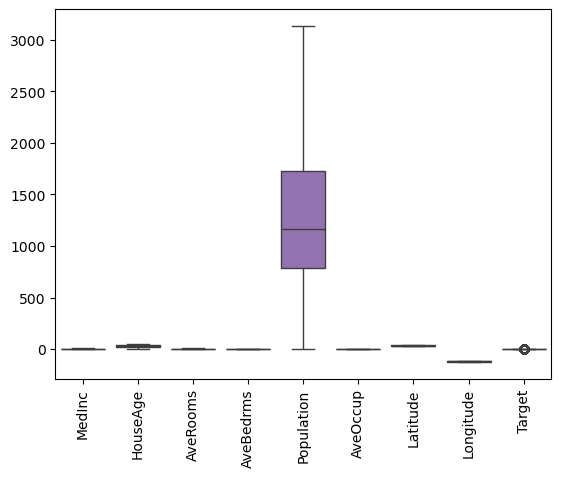

In [16]:
#Remove outliers in AveOccup
Q1=np.percentile(df['AveOccup'],25)
Q3=np.percentile(df['AveOccup'],75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
print("Q1:",Q1)
print("Q3:",Q3)
print("IQR:",IQR)
print("lower_bound:",lower_bound)
print("upper_bound:",upper_bound)
outliers=df[(df['AveOccup']<lower_bound)|(df['AveOccup']>upper_bound)]
print("Number of outliers:",len(outliers))
outliers
#clipping outliers
df['AveOccup']=df['AveOccup'].clip(lower_bound,upper_bound)
sns.boxplot(data=df)
plt.xticks(rotation=90)

Q1: 1.196
Q3: 2.6472499999999997
IQR: 1.4512499999999997
lower_bound: -0.9808749999999995
upper_bound: 4.824124999999999
Number of outliers: 1071


([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'MedInc'),
  Text(1, 0, 'HouseAge'),
  Text(2, 0, 'AveRooms'),
  Text(3, 0, 'AveBedrms'),
  Text(4, 0, 'Population'),
  Text(5, 0, 'AveOccup'),
  Text(6, 0, 'Latitude'),
  Text(7, 0, 'Longitude'),
  Text(8, 0, 'Target')])

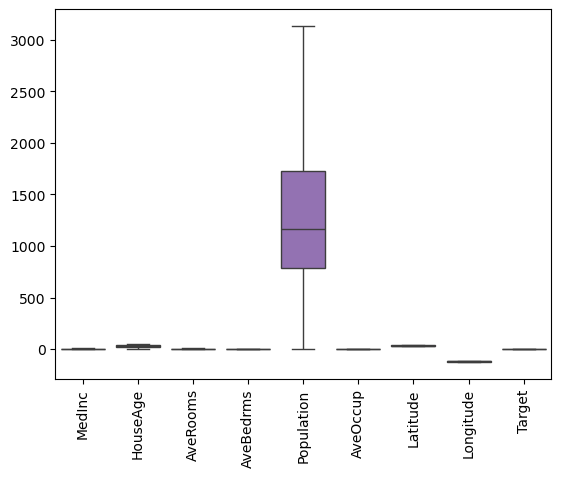

In [17]:
#Remove outliers in Target
Q1=np.percentile(df['Target'],25)
Q3=np.percentile(df['Target'],75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
print("Q1:",Q1)
print("Q3:",Q3)
print("IQR:",IQR)
print("lower_bound:",lower_bound)
print("upper_bound:",upper_bound)
outliers=df[(df['Target']<lower_bound)|(df['Target']>upper_bound)]
print("Number of outliers:",len(outliers))
outliers
#clipping outliers
df['Target']=df['Target'].clip(lower_bound,upper_bound)
sns.boxplot(data=df)
plt.xticks(rotation=90)

In [18]:
#Remove outliers in HouseAge
Q1=np.percentile(df['HouseAge'],25)
Q3=np.percentile(df['HouseAge'],75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
print("Q1:",Q1)
print("Q3:",Q3)
print("IQR:",IQR)
print("lower_bound:",lower_bound)
print("upper_bound:",upper_bound)
outliers=df[(df['HouseAge']<lower_bound)|(df['HouseAge']>upper_bound)]
print("Number of outliers:",len(outliers))
outliers

Q1: 18.0
Q3: 37.0
IQR: 19.0
lower_bound: -10.5
upper_bound: 65.5
Number of outliers: 0


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target


In [19]:
#Remove outliers in Latitude
Q1=np.percentile(df['Latitude'],25)
Q3=np.percentile(df['Latitude'],75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
print("Q1:",Q1)
print("Q3:",Q3)
print("IQR:",IQR)
print("lower_bound:",lower_bound)
print("upper_bound:",upper_bound)
outliers=df[(df['Latitude']<lower_bound)|(df['Latitude']>upper_bound)]
print("Number of outliers:",len(outliers))
outliers

Q1: 33.93
Q3: 37.71
IQR: 3.780000000000001
lower_bound: 28.259999999999998
upper_bound: 43.38
Number of outliers: 0


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target


In [20]:
#Remove outliers in Longitude
Q1=np.percentile(df['Longitude'],25)
Q3=np.percentile(df['Longitude'],75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
print("Q1:",Q1)
print("Q3:",Q3)
print("IQR:",IQR)
print("lower_bound:",lower_bound)
print("upper_bound:",upper_bound)
outliers=df[(df['Longitude']<lower_bound)|(df['Longitude']>upper_bound)]
print("Number of outliers:",len(outliers))
outliers

Q1: -121.8
Q3: -118.01
IQR: 3.789999999999992
lower_bound: -127.48499999999999
upper_bound: -112.32500000000002
Number of outliers: 0


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target


In [21]:
#No encoding since all are nuerical values

In [22]:
#feature selection
X = df.drop("Target", axis=1)
y = df["Target"]
print("FEATURES")
X.head()

FEATURES


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.013025,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.013025,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.257400,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.643100,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.846200,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [23]:
print("TARGET")
y.head()

TARGET


0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: Target, dtype: float64

In [24]:
print("Features:", X.columns)

Features: Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')


In [25]:
print("Target:", y.name)

Target: Target


In [26]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train:")
display(X_train)


X_train:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
14196,3.2596,33.0,5.017657,1.006421,2300.0,3.691814,32.71,-117.03
8267,3.8125,49.0,4.473545,1.041005,1314.0,1.738095,33.77,-118.16
17445,4.1563,4.0,5.645833,0.985119,915.0,2.723214,34.66,-120.48
14265,1.9425,36.0,4.002817,1.033803,1418.0,3.994366,32.69,-117.11
2271,3.5542,43.0,6.268421,1.134211,874.0,2.300000,36.78,-119.80
...,...,...,...,...,...,...,...,...
11284,6.3700,35.0,6.129032,0.926267,658.0,3.032258,33.78,-117.96
11964,3.0500,33.0,6.868597,1.239697,1753.0,3.904232,34.02,-117.43
5390,2.9344,36.0,3.986717,1.079696,1756.0,3.332068,34.03,-118.38
860,5.7192,15.0,6.395349,1.067979,1777.0,3.178891,37.58,-121.96


In [27]:
print("X_test:")
display(X_test)

X_test:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
20046,1.681200,25.0,4.192201,1.022284,1392.0,3.877437,36.06,-119.01
3024,2.531300,30.0,5.039384,1.193493,1565.0,2.679795,35.14,-119.46
15663,3.480100,52.0,3.977155,1.185877,1310.0,1.360332,37.80,-122.44
20484,5.737600,17.0,6.163636,1.020202,1705.0,3.444444,34.28,-118.72
9814,3.725000,34.0,5.492991,1.028037,1063.0,2.483645,36.62,-121.93
...,...,...,...,...,...,...,...,...
15362,4.605000,16.0,7.002212,1.066372,1351.0,2.988938,33.36,-117.22
16623,2.726600,28.0,6.131915,1.239697,1650.0,2.340426,35.36,-120.83
18086,8.013025,25.0,7.237676,0.947183,1585.0,2.790493,37.31,-122.05
2144,2.785000,36.0,5.289030,0.983122,1227.0,2.588608,36.77,-119.76


In [28]:
#Feature Scaling  
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
#Regression Algorithm Implementation 
#○ Linear Regression
#○ Decision Tree Regressor
#○ Random Forest Regressor
#○ Gradient Boosting Regressor
#○ Support Vector Regressor (SVR)


○ Linear Regression

Linear Regression finds the relationship between the input features and the target variable using a straight-line equation. It predicts the house price based on the given housing features.

Linear Regression works by finding the best-fit line between the input features and the target variable. It minimizes the difference between actual and predicted values

Why Linear Regression is suitable for this dataset :

Linear Regression is suitable because it provides a simple way to understand the relationship between housing features and median house prices. It can be used as a baseline model for predicting house prices

In [30]:
#A. Linear Regression
lin_reg= LinearRegression()
lin_reg.fit(X_train_scaled, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [31]:
y_pred_lr= lin_reg.predict(X_test_scaled)

In [32]:
df1=pd.DataFrame({"Actual":y_test,"Predicted":y_pred_lr})
df1

,Actual,Predicted
20046,0.477000,0.256541
3024,0.458000,1.966046
15663,4.824125,3.417614
20484,2.186000,2.726770
9814,2.780000,2.658567
...,...,...
15362,2.633000,2.082201
16623,2.668000,2.565132
18086,4.824125,4.043590
2144,0.723000,1.245915


In [33]:
linear_MSE=mean_squared_error(y_test,y_pred_lr)
linear_r2=r2_score(y_test,y_pred_lr)
linear_MAE=mean_absolute_error(y_test,y_pred_lr)
linear_RMSE=np.sqrt(linear_MSE)
print("Mean Square Error:",linear_MSE)
print("R2 Score:",linear_r2)
print("Mean Absolute Error:",linear_MAE)
print("RMSE Error:",linear_RMSE)

Mean Square Error: 0.44240911992742304
R2 Score: 0.6500913755505535
Mean Absolute Error: 0.49466712713252625
RMSE Error: 0.6651384216292298


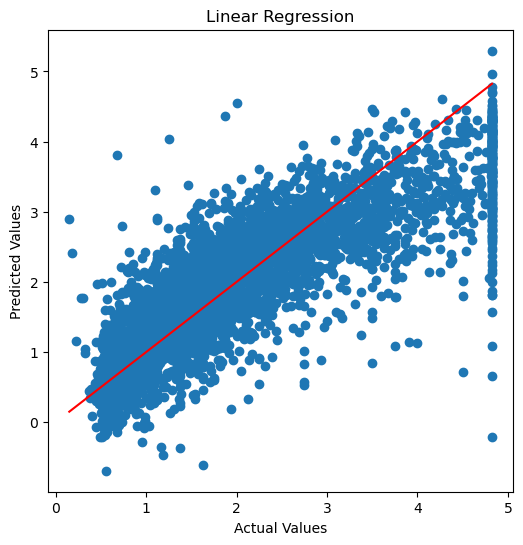

In [34]:
import matplotlib.pyplot as plt

# Predict on the test data
y_pred_lr= lin_reg.predict(X_test_scaled)
plt.figure(figsize=(6,6))

# Scatter plot of actual vs predicted values
plt.scatter(y_test, y_pred_lr)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Linear Regression")

plt.show()

○ Decision Tree Regressor

Decision Tree Regressor is a machine learning algorithm that predicts a continuous value by dividing the data into smaller groups using decision rules.

It splits the data based on feature values and creates branches. At the final leaf nodes, it predicts the target value based on the data in that group.

Suitable for the Dataset:

It is suitable for the California Housing dataset because it can capture non-linear relationships between housing features and house prices.



In [35]:
#B. Decision Tree Regresson

dt= DecisionTreeRegressor(max_depth=5,random_state=42)
dt.fit(X_train, y_train)



,criterion,'squared_error'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [36]:
y_pred_dt = dt.predict(X_test)
dt_MSE=mean_squared_error(y_test,y_pred_dt)
dt_r2=r2_score(y_test,y_pred_dt)
dt_MAE=mean_absolute_error(y_test,y_pred_dt)
print("Decision Tree Regressor")
print("Mean Square Error:",dt_MSE)
print("R2 Score:",dt_r2)
print("Mean Absolute Error:",dt_MAE)


Decision Tree Regressor
Mean Square Error: 0.5054547848632559
R2 Score: 0.6002275257754474
Mean Absolute Error: 0.5166981551037456


In [37]:
df2=pd.DataFrame({"Actual":y_test,"Predicted":y_pred_dt})
df2

,Actual,Predicted
20046,0.477000,1.168191
3024,0.458000,1.271416
15663,4.824125,3.170273
20484,2.186000,2.172118
9814,2.780000,1.642538
...,...,...
15362,2.633000,1.908279
16623,2.668000,1.271416
18086,4.824125,4.649198
2144,0.723000,1.271416


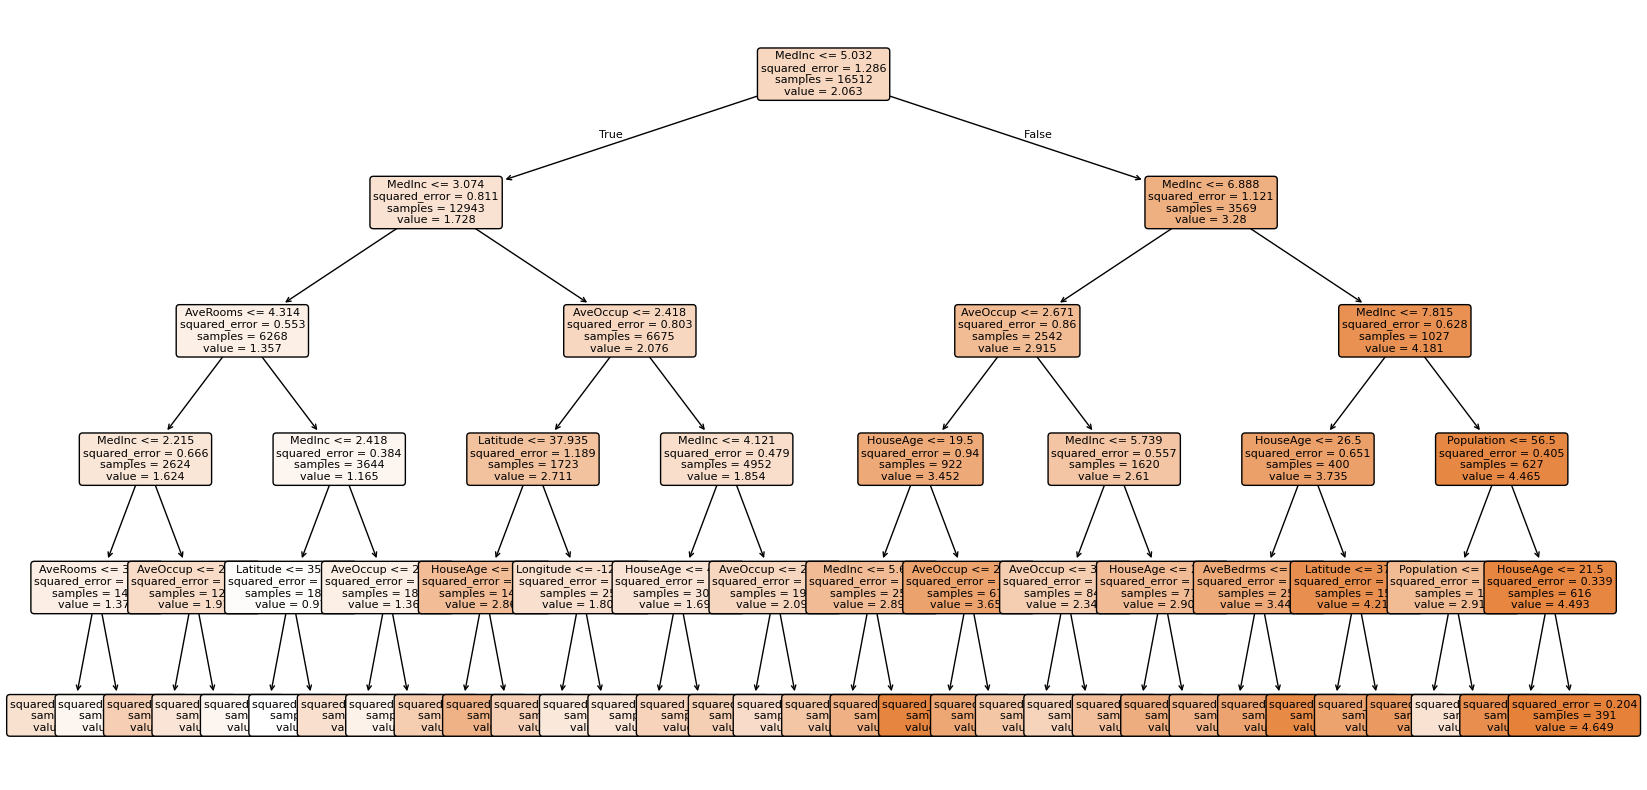

In [38]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(20,10))
plot_tree(dt,feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=8)
plt.show()


○ Random Forest Regressor

Random Forest Regressor is an ensemble machine learning algorithm that combines multiple Decision Trees to predict a continuous value.
improve accuracy and reduce overfitting.
It is robust and performs well on complex datasets.    

It creates multiple Decision Trees using different samples of the data and features. The predictions from all trees are combined, usually by taking their average, to produce the final prediction.

Suitable for the Dataset:

It is suitable for the California Housing dataset because it can handle complex and non-linear relationships between housing features and house prices.

In [39]:
# 3. Random forest regressor
rf=RandomForestRegressor(random_state=42,max_depth=5)
rf.fit(X_train,y_train)


,n_estimators,100
,criterion,'squared_error'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [40]:

y_pred_rf=rf.predict(X_test)
rf_r2=r2_score(y_test,y_pred_rf)
rf_mse=mean_squared_error(y_test,y_pred_rf)
rf_mae=mean_absolute_error(y_test,y_pred_rf)
print("Random forest regressor")
print("Mean Square Error:",rf_mse)
print("R2 Score:",rf_r2)
print("Mean Absolute Error:",rf_mae)

Random forest regressor
Mean Square Error: 0.4465485333077955
R2 Score: 0.646817445659164
Mean Absolute Error: 0.48603377692065936


In [41]:
df3=pd.DataFrame({"Actual":y_test,"Predicted":y_pred_rf})
df3

,Actual,Predicted
20046,0.477000,1.041271
3024,0.458000,1.103105
15663,4.824125,3.441442
20484,2.186000,2.423829
9814,2.780000,1.687420
...,...,...
15362,2.633000,1.963304
16623,2.668000,1.157050
18086,4.824125,4.553615
2144,0.723000,1.114618


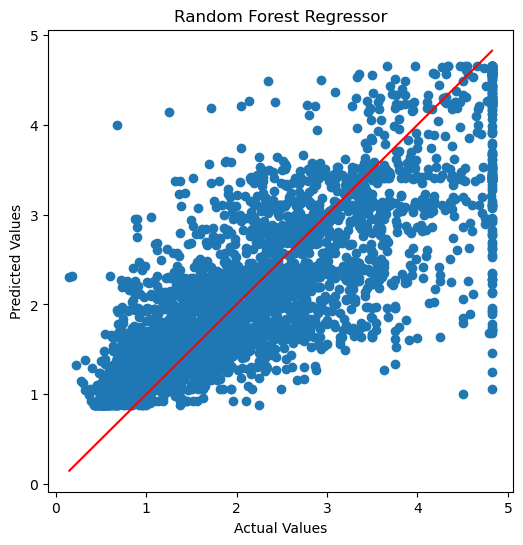

In [42]:
plt.figure(figsize=(6,6))

# Actual vs Predicted
plt.scatter(y_test, y_pred_rf)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest Regressor")

plt.show()

○ Gradient Boosting Regressor

Gradient Boosting Regressor is an ensemble machine learning algorithm that combines multiple weak decision trees to make accurate predictions.

It builds decision trees one after another. Each new tree tries to reduce the errors made by the previous trees. Finally, all the trees are combined to make the prediction.

Suitable for the Dataset:

It is suitable for the California Housing dataset because it can capture complex and non-linear relationships between housing features and house prices.



In [43]:
# 4.GradientBoosting Regressor

gb=GradientBoostingRegressor(random_state=42,max_depth=5)
gb.fit(X_train,y_train)



,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,5
,min_impurity_decrease,0.0
,init,None


In [44]:
y_pred_gb=gb.predict(X_test)
gb_r2=r2_score(y_test,y_pred_gb)
gb_mse=mean_squared_error(y_test,y_pred_gb)
gb_mae=mean_absolute_error(y_test,y_pred_gb)

print("GradientBoosting Regressor")
print("Mean Square Error:",gb_mse)
print("R2 Score:",gb_r2)
print("Mean Absolute Error:",gb_mae)

GradientBoosting Regressor
Mean Square Error: 0.2336645837807008
R2 Score: 0.8151908507069874
Mean Absolute Error: 0.32771314405007834


In [45]:
df4=pd.DataFrame({"Actual":y_test,"Predicted":y_pred_gb})
df4

,Actual,Predicted
20046,0.477000,0.446870
3024,0.458000,1.024400
15663,4.824125,4.487963
20484,2.186000,2.508146
9814,2.780000,2.275777
...,...,...
15362,2.633000,2.255590
16623,2.668000,1.857824
18086,4.824125,4.731873
2144,0.723000,0.789608


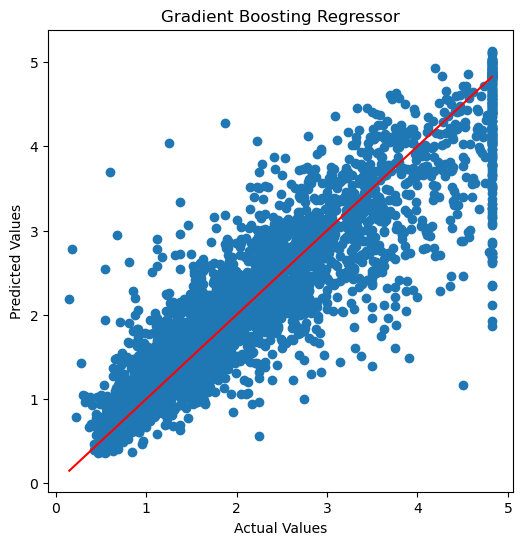

In [46]:
plt.figure(figsize=(6,6))

# Actual vs Predicted
plt.scatter(y_test, y_pred_gb)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Gradient Boosting Regressor")

plt.show()

○ Support Vector Regressor (SVR)

SVR is a regression algorithm that predicts a continuous value by finding a suitable function within a defined error margin.

SVR tries to find the best-fitting function while allowing small errors within a specified margin.

It uses a kernel to handle non-linear relationships.

Suitable for the Dataset:

SVR is suitable for the California Housing dataset because it can model non-linear relationships between housing features and house prices. 
It also works well when the features are scaled.

In [47]:
# 5. SVM Rregressor

svr=SVR()
svr.fit(X_train_scaled,y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [48]:
y_pred_svr=svr.predict(X_test_scaled)
svr_r2=r2_score(y_test,y_pred_svr)
svr_mse=mean_squared_error(y_test,y_pred_svr)
svr_mae=mean_absolute_error(y_test,y_pred_svr)

print("SVR")
print("Mean Square Error:",svr_mse)
print("R2 Score:",svr_r2)
print("Mean Absolute Error:",svr_mae)

SVR
Mean Square Error: 0.29972841936726485
R2 Score: 0.7629398802935808
Mean Absolute Error: 0.3687030011534401


In [49]:
df5=pd.DataFrame({"Actual":y_test,"Predicted":y_pred_svr})
df5

,Actual,Predicted
20046,0.477000,0.476665
3024,0.458000,1.460944
15663,4.824125,4.599955
20484,2.186000,2.311717
9814,2.780000,2.639462
...,...,...
15362,2.633000,2.072879
16623,2.668000,2.250222
18086,4.824125,4.508382
2144,0.723000,0.591369


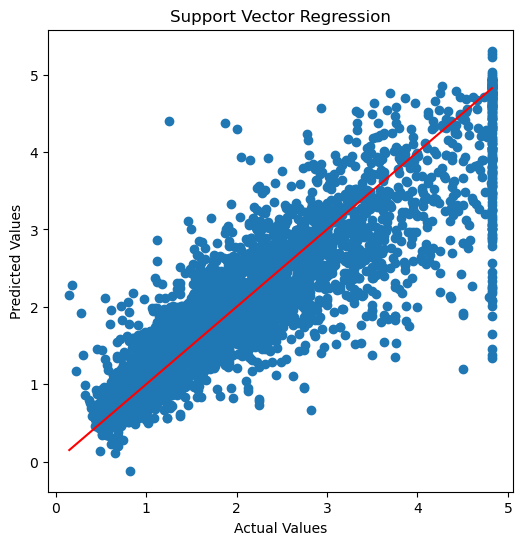

In [50]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_svr)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Support Vector Regression")

plt.show()

In [51]:
#Model Evaluation and Comparison (2 marks):
#Evaluate the performance of each algorithm using the following metrics;
#Mean Squared Error (MSE)
#Mean Absolute Error (MAE)
#R-squared Score (R)
#Compare the results of all models and identify: 
#The best-performing algorithm with justification and the worst-performing algorithm with reasoning

In [52]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting',
        'SVR'
    ],
    'MSE': [
        linear_MSE,
        dt_MSE,
        rf_mse,
        gb_mse,
        svr_mse
    ],
    'MAE': [
        linear_MAE,
        dt_MAE,
        rf_mae,
        gb_mae,
        svr_mae
    ],
    'R2 Score': [
        linear_r2,
        dt_r2,
        rf_r2,
        gb_r2,
        svr_r2
    ]
})

print(results)

               Model       MSE       MAE  R2 Score
0  Linear Regression  0.442409  0.494667  0.650091
1      Decision Tree  0.505455  0.516698  0.600228
2      Random Forest  0.446549  0.486034  0.646817
3  Gradient Boosting  0.233665  0.327713  0.815191
4                SVR  0.299728  0.368703  0.762940


In [53]:
#The best-performing algorithm with justification
best_mse = results.loc[results["MSE"].idxmin(), "Model"]
best_mae = results.loc[results["MAE"].idxmin(), "Model"]
best_r2 = results.loc[results["R2 Score"].idxmax(), "Model"]

print("Best MSE:", best_mse)
print("Best MAE:", best_mae)
print("Best R²:", best_r2)

Best MSE: Gradient Boosting
Best MAE: Gradient Boosting
Best R²: Gradient Boosting


Best-Performing Algorithm

Model performed best because it achieved the lowest MSE and MAE and the highest R² Score among the models.
    
This indicates that it made more accurate predictions with lower errors.

In [54]:
#the worst-performing algorithm with reasoning
worst_mse = results.loc[results["MSE"].idxmax(), "Model"]
worst_mae = results.loc[results["MAE"].idxmax(), "Model"]
worst_r2 = results.loc[results["R2 Score"].idxmin(), "Model"]

print("Worst MSE:", worst_mse)
print("Worst MAE:", worst_mae)
print("Worst R²:", worst_r2)

Worst MSE: Decision Tree
Worst MAE: Decision Tree
Worst R²: Decision Tree


Worst-Performing Algorithm

Model performed worst because it had the highest MSE and MAE and the lowest R2 Score among the models. 
    
This indicates that its predictions had larger errors compared with the other models.

In [55]:
best_model = results.loc[results['R2 Score'].idxmax(), 'Model']
worst_model = results.loc[results['R2 Score'].idxmin(), 'Model']

print("Best performing model:", best_model)
print("Worst performing model:", worst_model)

Best performing model: Gradient Boosting
Worst performing model: Decision Tree
